In [1]:
import os
import math
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.utils as vutils

import matplotlib.pyplot as plt

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

IMAGE_SIZE = 64
CHANNELS_IMG = 3
ATTR_DIM = 40

BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-4

NUM_WORKERS = 1
DISPLAY_EVERY = 5

SAVE_DIR = "celeba_conditional_diffusion_runs"
os.makedirs(SAVE_DIR, exist_ok=True)

Device: cuda


In [3]:
IMG_DIR = "/home/rja3097/CelebA/CelebA dataset/img_align_celeba/img_align_celeba"
ATTR_PATH = "/home/rja3097/CelebA/CelebA dataset/list_attr_celeba.csv"

In [4]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_path, transform=None):
        self.img_dir = img_dir
        self.attrs = pd.read_csv(attr_path)
        self.transform = transform

        self.image_names = self.attrs.iloc[:, 0].values
        self.attr_names = list(self.attrs.columns[1:])

        self.labels = self.attrs.iloc[:, 1:].values
        self.labels = (self.labels + 1) // 2
        self.labels = self.labels.astype("float32")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        attrs = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, attrs

In [5]:
transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

dataset = CelebADataset(
    img_dir=IMG_DIR,
    attr_path=ATTR_PATH,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataset size:", len(dataset))
print("Attributes:", dataset.attr_names)

Dataset size: 202599
Attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


In [6]:
def offset_cosine_diffusion_schedule(diffusion_times):
    min_signal_rate = 0.02
    max_signal_rate = 0.95

    start_angle = torch.acos(torch.tensor(max_signal_rate, device=diffusion_times.device))
    end_angle = torch.acos(torch.tensor(min_signal_rate, device=diffusion_times.device))

    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

    signal_rates = torch.cos(diffusion_angles)
    noise_rates = torch.sin(diffusion_angles)

    return noise_rates, signal_rates

In [7]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, diffusion_times):
        half_dim = self.embedding_dim // 2

        frequencies = torch.exp(
            torch.linspace(
                math.log(1.0),
                math.log(1000.0),
                half_dim,
                device=diffusion_times.device
            )
        )

        angles = diffusion_times * frequencies.view(1, -1)

        embeddings = torch.cat(
            [torch.sin(angles), torch.cos(angles)],
            dim=-1
        )

        return embeddings

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)

        self.cond_proj = nn.Linear(cond_dim, out_channels)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

        self.act = nn.SiLU()

    def forward(self, x, cond):
        h = self.conv1(x)
        h = self.norm1(h)

        cond_emb = self.cond_proj(cond).unsqueeze(-1).unsqueeze(-1)
        h = h + cond_emb

        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)

        return self.act(h + self.skip(x))

In [9]:
class ConditionalUNet(nn.Module):
    def __init__(self, img_channels=3, attr_dim=40, time_dim=128, base_channels=64):
        super().__init__()

        self.time_embedding = SinusoidalEmbedding(time_dim)

        self.cond_mlp = nn.Sequential(
            nn.Linear(time_dim + attr_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim * 4),
            nn.SiLU()
        )

        cond_dim = time_dim * 4

        self.init_conv = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        self.down1 = ResidualBlock(base_channels, base_channels, cond_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1)

        self.down2 = ResidualBlock(base_channels * 2, base_channels * 2, cond_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1)

        self.down3 = ResidualBlock(base_channels * 4, base_channels * 4, cond_dim)
        self.downsample3 = nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1)

        self.mid1 = ResidualBlock(base_channels * 8, base_channels * 8, cond_dim)
        self.mid2 = ResidualBlock(base_channels * 8, base_channels * 8, cond_dim)

        self.upsample3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1)
        self.up3 = ResidualBlock(base_channels * 8, base_channels * 4, cond_dim)

        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1)
        self.up2 = ResidualBlock(base_channels * 4, base_channels * 2, cond_dim)

        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1)
        self.up1 = ResidualBlock(base_channels * 2, base_channels, cond_dim)

        self.out = nn.Conv2d(base_channels, img_channels, 1)

    def forward(self, x, diffusion_times, attrs):
        if diffusion_times.ndim == 4:
            diffusion_times = diffusion_times.view(diffusion_times.size(0), 1)

        time_emb = self.time_embedding(diffusion_times)
        cond = torch.cat([time_emb, attrs], dim=1)
        cond = self.cond_mlp(cond)

        x = self.init_conv(x)

        d1 = self.down1(x, cond)
        x = self.downsample1(d1)

        d2 = self.down2(x, cond)
        x = self.downsample2(d2)

        d3 = self.down3(x, cond)
        x = self.downsample3(d3)

        x = self.mid1(x, cond)
        x = self.mid2(x, cond)

        x = self.upsample3(x)
        x = torch.cat([x, d3], dim=1)
        x = self.up3(x, cond)

        x = self.upsample2(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up2(x, cond)

        x = self.upsample1(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up1(x, cond)

        return self.out(x)

In [10]:
class DiffusionModel(nn.Module):
    def __init__(self, network):
        super().__init__()

        self.network = network
        self.ema_network = ConditionalUNet(
            img_channels=CHANNELS_IMG,
            attr_dim=ATTR_DIM,
            time_dim=128,
            base_channels=64
        ).to(DEVICE)

        self.ema_network.load_state_dict(self.network.state_dict())

    def denoise(self, noisy_images, noise_rates, signal_rates, attrs, training=True):
        if training:
            network = self.network
        else:
            network = self.ema_network

        diffusion_times = torch.atan2(noise_rates, signal_rates)

        pred_noises = network(noisy_images, diffusion_times, attrs)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates

        return pred_noises, pred_images

    @torch.no_grad()
    def update_ema(self, decay=0.999):
        for ema_param, param in zip(self.ema_network.parameters(), self.network.parameters()):
            ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

In [11]:
unet = ConditionalUNet(
    img_channels=CHANNELS_IMG,
    attr_dim=ATTR_DIM,
    time_dim=128,
    base_channels=64
).to(DEVICE)

diffusion_model = DiffusionModel(unet).to(DEVICE)

optimizer = optim.AdamW(
    diffusion_model.network.parameters(),
    lr=LR,
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()

In [12]:
@torch.no_grad()
def generate_images(model, attrs, num_steps=50):
    model.eval()

    batch_size = attrs.size(0)
    images = torch.randn(
        batch_size,
        CHANNELS_IMG,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )

    step_size = 1.0 / num_steps

    for step in tqdm(range(num_steps), desc="Sampling", leave=False):
        diffusion_times = torch.ones(
            batch_size,
            1,
            1,
            1,
            device=DEVICE
        ) - step * step_size

        noise_rates, signal_rates = offset_cosine_diffusion_schedule(diffusion_times)

        pred_noises, pred_images = model.denoise(
            images,
            noise_rates,
            signal_rates,
            attrs,
            training=False
        )

        next_diffusion_times = diffusion_times - step_size
        next_diffusion_times = torch.clamp(next_diffusion_times, min=0.0)

        next_noise_rates, next_signal_rates = offset_cosine_diffusion_schedule(
            next_diffusion_times
        )

        images = (
            next_signal_rates * pred_images
            + next_noise_rates * pred_noises
        )

    images = torch.clamp(pred_images, -1.0, 1.0)
    return images

In [13]:
def show_real_vs_generated(real_imgs, gen_imgs, nrow=8):
    real_imgs = real_imgs[:64].detach().cpu()
    gen_imgs = gen_imgs[:64].detach().cpu()

    real_imgs = (real_imgs + 1) / 2
    gen_imgs = (gen_imgs + 1) / 2

    real_grid = vutils.make_grid(real_imgs, nrow=nrow, padding=2)
    gen_grid = vutils.make_grid(gen_imgs, nrow=nrow, padding=2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(real_grid.permute(1, 2, 0))
    axes[0].set_title("Real CelebA Faces")
    axes[0].axis("off")

    axes[1].imshow(gen_grid.permute(1, 2, 0))
    axes[1].set_title("Generated Faces")
    axes[1].axis("off")

    plt.show()

In [14]:
sample_imgs, sample_attrs = next(iter(loader))

fixed_real = sample_imgs[:64].to(DEVICE)
fixed_attrs = sample_attrs[:64].to(DEVICE)

Epoch 1/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Finished epoch 1


Epoch 2/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Finished epoch 3


Epoch 4/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home

Finished epoch 4


Epoch 5/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

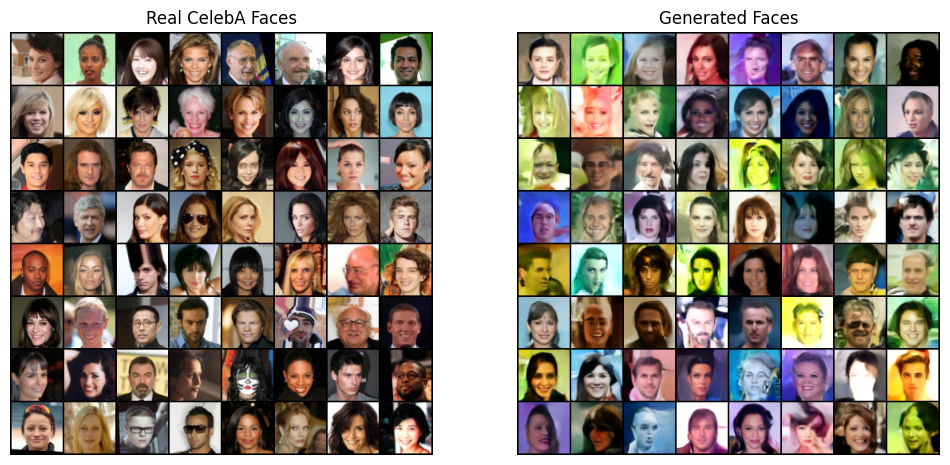

Finished epoch 5


Epoch 6/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Finished epoch 6


Epoch 7/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Finished epoch 9


Epoch 10/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

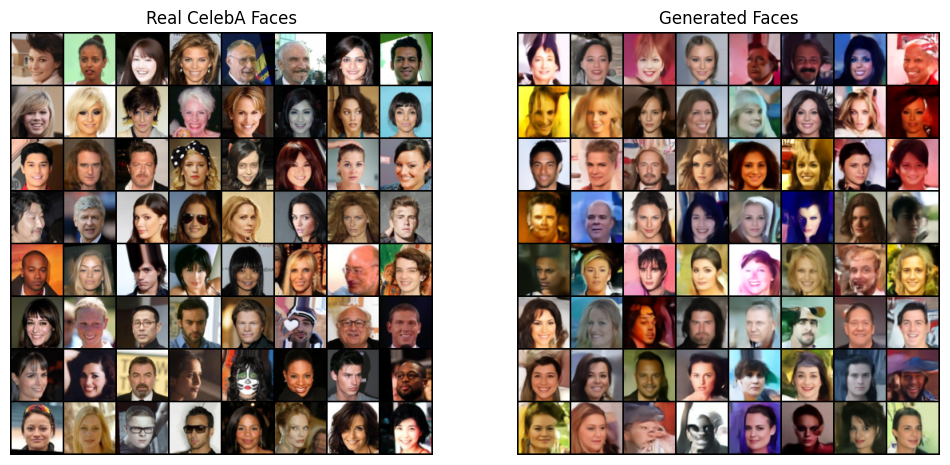

Finished epoch 10


Epoch 11/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Finished epoch 11


Epoch 12/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Finished epoch 12


Epoch 13/50:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14b4a4bd57e0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
Exception ign

Finished epoch 13


Epoch 14/50:   0%|          | 0/1583 [00:00<?, ?it/s]

In [ ]:
losses = []

for epoch in range(1, EPOCHS + 1):
    diffusion_model.network.train()

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)

    for images, attrs in pbar:
        images = images.to(DEVICE, non_blocking=True)
        attrs = attrs.to(DEVICE, non_blocking=True)

        batch_size = images.shape[0]

        noises = torch.randn_like(images)

        diffusion_times = torch.rand(
            batch_size,
            1,
            1,
            1,
            device=DEVICE
        )

        noise_rates, signal_rates = offset_cosine_diffusion_schedule(diffusion_times)

        noisy_images = signal_rates * images + noise_rates * noises

        pred_noises, pred_images = diffusion_model.denoise(
            noisy_images,
            noise_rates,
            signal_rates,
            attrs,
            training=True
        )

        noise_loss = loss_fn(pred_noises, noises)

        optimizer.zero_grad(set_to_none=True)
        noise_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            diffusion_model.network.parameters(),
            max_norm=1.0
        )
        optimizer.step()

        diffusion_model.update_ema(decay=0.999)

        losses.append(noise_loss.item())

        pbar.set_postfix({
            "noise_loss": f"{noise_loss.item():.4f}"
        })

    torch.save({
        "epoch": epoch,
        "network_state_dict": diffusion_model.network.state_dict(),
        "ema_network_state_dict": diffusion_model.ema_network.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "losses": losses,
        "attr_names": dataset.attr_names,
        "image_size": IMAGE_SIZE,
    }, f"{SAVE_DIR}/checkpoint_latest.pt")

    if epoch % DISPLAY_EVERY == 0:
        diffusion_model.eval()

        generated = generate_images(
            diffusion_model,
            fixed_attrs,
            num_steps=50
        )

        vutils.save_image(
            (fixed_real + 1) / 2,
            f"{SAVE_DIR}/real_reference.png",
            nrow=8
        )

        vutils.save_image(
            (generated + 1) / 2,
            f"{SAVE_DIR}/generated_epoch_{epoch:03d}.png",
            nrow=8
        )

        show_real_vs_generated(
            fixed_real,
            generated,
            nrow=8
        )

        torch.save({
            "epoch": epoch,
            "network_state_dict": diffusion_model.network.state_dict(),
            "ema_network_state_dict": diffusion_model.ema_network.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "losses": losses,
            "attr_names": dataset.attr_names,
            "image_size": IMAGE_SIZE,
        }, f"{SAVE_DIR}/checkpoint_epoch_{epoch:03d}.pt")

    print(f"Finished epoch {epoch}")

In [16]:
ckpt = torch.load("/home/rja3097/CelebA/celeba_conditional_diffusion_runs/checkpoint_epoch_090.pt", map_location="cpu")
print(ckpt.keys())


/tmp/ipykernel_3765585/1612074570.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/home/rja3097/CelebA/celeba_conditional_diffusion_runs/checkpoint_ep

dict_keys(['epoch', 'network_state_dict', 'ema_network_state_dict', 'optimizer_state_dict', 'losses', 'attr_names', 'image_size'])


In [15]:
# ---------------------
# Load checkpoint
# ---------------------
ckpt = torch.load(
    "/home/rja3097/CelebA/celeba_conditional_diffusion_runs/checkpoint_latest.pt",
    map_location=DEVICE
)

diffusion_model.network.load_state_dict(ckpt["network_state_dict"])
diffusion_model.ema_network.load_state_dict(ckpt["ema_network_state_dict"])
optimizer.load_state_dict(ckpt["optimizer_state_dict"])

losses = ckpt["losses"]

start_epoch = ckpt["epoch"] + 1
EPOCHS = 200

print(f"Resuming from epoch {start_epoch} \u2192 {EPOCHS}")


/tmp/ipykernel_3917609/646526874.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(


Resuming from epoch 195 → 200


Epoch 195/200:   0%|          | 0/1583 [00:00<?, ?it/s]

Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

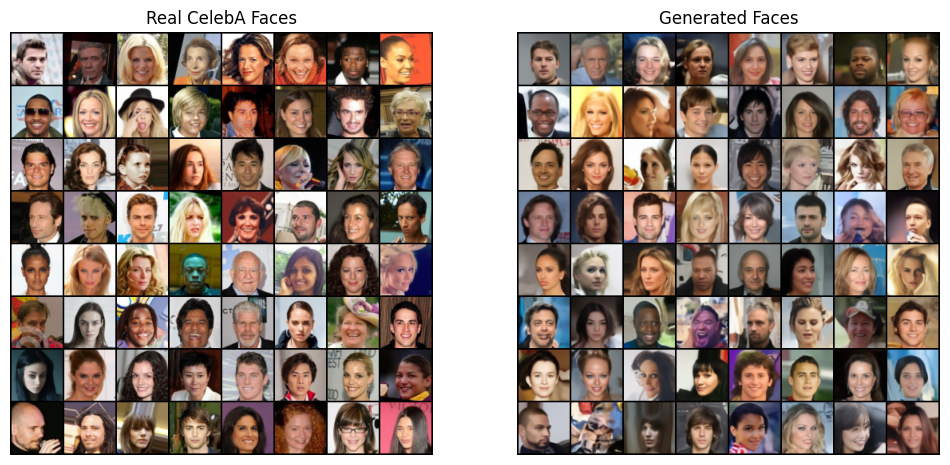

Finished epoch 195


Epoch 196/200:   0%|          | 0/1583 [00:00<?, ?it/s]

Finished epoch 196


Epoch 197/200:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x153653071bd0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

Epoch 199/200:   0%|          | 0/1583 [00:00<?, ?it/s]

Finished epoch 199


Epoch 200/200:   0%|          | 0/1583 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x153653071bd0>
Traceback (most recent call last):
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/rja3097/.conda/envs/kernel-for-gen-ai/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

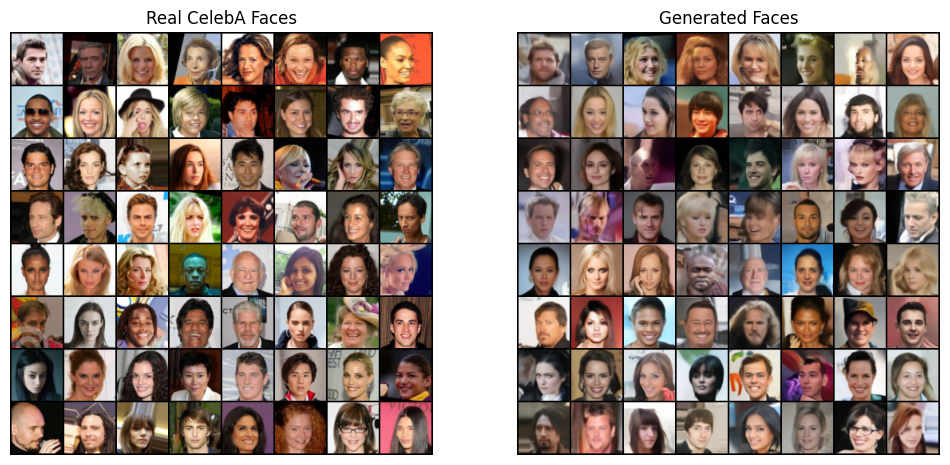

Finished epoch 200


In [16]:
# ---------------------
# Resume training loop
# ---------------------
for epoch in range(start_epoch, EPOCHS + 1):
    diffusion_model.network.train()

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)

    for images, attrs in pbar:
        images = images.to(DEVICE, non_blocking=True)
        attrs = attrs.to(DEVICE, non_blocking=True)

        batch_size = images.shape[0]

        noises = torch.randn_like(images)

        diffusion_times = torch.rand(
            batch_size,
            1,
            1,
            1,
            device=DEVICE
        )

        noise_rates, signal_rates = offset_cosine_diffusion_schedule(diffusion_times)

        noisy_images = signal_rates * images + noise_rates * noises

        pred_noises, pred_images = diffusion_model.denoise(
            noisy_images,
            noise_rates,
            signal_rates,
            attrs,
            training=True
        )

        noise_loss = loss_fn(pred_noises, noises)

        optimizer.zero_grad(set_to_none=True)
        noise_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            diffusion_model.network.parameters(),
            max_norm=1.0
        )
        optimizer.step()

        diffusion_model.update_ema(decay=0.999)

        losses.append(noise_loss.item())

        pbar.set_postfix({
            "noise_loss": f"{noise_loss.item():.4f}"
        })

    torch.save({
        "epoch": epoch,
        "network_state_dict": diffusion_model.network.state_dict(),
        "ema_network_state_dict": diffusion_model.ema_network.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "losses": losses,
        "attr_names": dataset.attr_names,
        "image_size": IMAGE_SIZE,
    }, f"{SAVE_DIR}/checkpoint_latest.pt")

    if epoch % DISPLAY_EVERY == 0:
        diffusion_model.eval()

        generated = generate_images(
            diffusion_model,
            fixed_attrs,
            num_steps=50
        )

        vutils.save_image(
            (fixed_real + 1) / 2,
            f"{SAVE_DIR}/real_reference.png",
            nrow=8
        )

        vutils.save_image(
            (generated + 1) / 2,
            f"{SAVE_DIR}/generated_epoch_{epoch:03d}.png",
            nrow=8
        )

        show_real_vs_generated(
            fixed_real,
            generated,
            nrow=8
        )

        torch.save({
            "epoch": epoch,
            "network_state_dict": diffusion_model.network.state_dict(),
            "ema_network_state_dict": diffusion_model.ema_network.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "losses": losses,
            "attr_names": dataset.attr_names,
            "image_size": IMAGE_SIZE,
        }, f"{SAVE_DIR}/checkpoint_epoch_{epoch:03d}.pt")

    print(f"Finished epoch {epoch}")


In [1]:
!pip install clean-fid

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 131.8 MB/s eta 0:00:0000:01


## Finding Best Epoch Checkpoint

In [1]:
import os
import math
import glob
import json

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.utils as vutils
import matplotlib
matplotlib.use("Agg")          # headless – no display needed
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# CONFIG  ← edit these paths to match your setup
# ─────────────────────────────────────────────
IMG_DIR   = "/home/rja3097/CelebA/CelebA dataset/img_align_celeba/img_align_celeba"
ATTR_PATH = "/home/rja3097/CelebA/CelebA dataset/list_attr_celeba.csv"
SAVE_DIR  = "/home/rja3097/CelebA/celeba_conditional_diffusion_runs"

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE  = 64
CHANNELS    = 3
ATTR_DIM    = 40
VAL_FRAC    = 0.10          # 5 % of dataset used for val loss  (~10k images)
VAL_BATCH   = 64
GEN_BATCH   = 64            # images to generate per checkpoint for FID
NUM_STEPS   = 50            # denoising steps
NROW        = 8             # columns in visual grids

EVAL_DIR    = os.path.join(SAVE_DIR, "eval_results")
GRID_DIR    = os.path.join(EVAL_DIR, "grids")
REAL_DIR    = os.path.join(EVAL_DIR, "real_for_fid")
os.makedirs(GRID_DIR,  exist_ok=True)
os.makedirs(REAL_DIR,  exist_ok=True)

# ─────────────────────────────────────────────
# Model definitions  (must match training code)
# ─────────────────────────────────────────────

def offset_cosine_diffusion_schedule(diffusion_times):
    min_signal_rate = 0.02
    max_signal_rate = 0.95
    start_angle = torch.acos(torch.tensor(max_signal_rate, device=diffusion_times.device))
    end_angle   = torch.acos(torch.tensor(min_signal_rate, device=diffusion_times.device))
    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)
    return torch.sin(diffusion_angles), torch.cos(diffusion_angles)   # noise, signal


class SinusoidalEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, diffusion_times):
        half_dim   = self.embedding_dim // 2
        frequencies = torch.exp(
            torch.linspace(math.log(1.0), math.log(1000.0), half_dim,
                           device=diffusion_times.device)
        )
        angles = diffusion_times * frequencies.view(1, -1)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.conv1     = nn.Conv2d(in_channels,  out_channels, 3, padding=1)
        self.norm1     = nn.GroupNorm(8, out_channels)
        self.conv2     = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2     = nn.GroupNorm(8, out_channels)
        self.cond_proj = nn.Linear(cond_dim, out_channels)
        self.skip      = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.act       = nn.SiLU()

    def forward(self, x, cond):
        h = self.norm1(self.conv1(x))
        h = h + self.cond_proj(cond).unsqueeze(-1).unsqueeze(-1)
        h = self.act(h)
        h = self.norm2(self.conv2(h))
        return self.act(h + self.skip(x))


class ConditionalUNet(nn.Module):
    def __init__(self, img_channels=3, attr_dim=40, time_dim=128, base_channels=64):
        super().__init__()
        C = base_channels
        self.time_embedding = SinusoidalEmbedding(time_dim)
        self.cond_mlp = nn.Sequential(
            nn.Linear(time_dim + attr_dim, time_dim * 4), nn.SiLU(),
            nn.Linear(time_dim * 4,        time_dim * 4), nn.SiLU(),
        )
        cd = time_dim * 4
        self.init_conv    = nn.Conv2d(img_channels, C, 3, padding=1)
        self.down1        = ResidualBlock(C,     C,     cd)
        self.downsample1  = nn.Conv2d(C,   C*2, 4, 2, 1)
        self.down2        = ResidualBlock(C*2,  C*2,   cd)
        self.downsample2  = nn.Conv2d(C*2, C*4, 4, 2, 1)
        self.down3        = ResidualBlock(C*4,  C*4,   cd)
        self.downsample3  = nn.Conv2d(C*4, C*8, 4, 2, 1)
        self.mid1         = ResidualBlock(C*8,  C*8,   cd)
        self.mid2         = ResidualBlock(C*8,  C*8,   cd)
        self.upsample3    = nn.ConvTranspose2d(C*8, C*4, 4, 2, 1)
        self.up3          = ResidualBlock(C*8,  C*4,   cd)
        self.upsample2    = nn.ConvTranspose2d(C*4, C*2, 4, 2, 1)
        self.up2          = ResidualBlock(C*4,  C*2,   cd)
        self.upsample1    = nn.ConvTranspose2d(C*2, C,   4, 2, 1)
        self.up1          = ResidualBlock(C*2,  C,     cd)
        self.out          = nn.Conv2d(C, img_channels, 1)

    def forward(self, x, diffusion_times, attrs):
        if diffusion_times.ndim == 4:
            diffusion_times = diffusion_times.view(diffusion_times.size(0), 1)
        cond = self.cond_mlp(torch.cat([self.time_embedding(diffusion_times), attrs], dim=1))
        x  = self.init_conv(x)
        d1 = self.down1(x,  cond);  x = self.downsample1(d1)
        d2 = self.down2(x,  cond);  x = self.downsample2(d2)
        d3 = self.down3(x,  cond);  x = self.downsample3(d3)
        x  = self.mid2(self.mid1(x, cond), cond)
        x  = self.upsample3(x); x = self.up3(torch.cat([x, d3], 1), cond)
        x  = self.upsample2(x); x = self.up2(torch.cat([x, d2], 1), cond)
        x  = self.upsample1(x); x = self.up1(torch.cat([x, d1], 1), cond)
        return self.out(x)


class DiffusionModel(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network     = network
        self.ema_network = ConditionalUNet(CHANNELS, ATTR_DIM, 128, 64).to(DEVICE)
        self.ema_network.load_state_dict(network.state_dict())

    def denoise(self, noisy, noise_rates, signal_rates, attrs, training=True):
        net = self.network if training else self.ema_network
        dt  = torch.atan2(noise_rates, signal_rates)
        pred_noises = net(noisy, dt, attrs)
        pred_images = (noisy - noise_rates * pred_noises) / signal_rates
        return pred_noises, pred_images

    @torch.no_grad()
    def update_ema(self, decay=0.999):
        for ep, p in zip(self.ema_network.parameters(), self.network.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1 - decay)


# ─────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────

class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_path, transform=None):
        self.img_dir    = img_dir
        attrs           = pd.read_csv(attr_path)
        self.image_names = attrs.iloc[:, 0].values
        self.attr_names  = list(attrs.columns[1:])
        labels           = attrs.iloc[:, 1:].values
        labels           = ((labels + 1) // 2).astype("float32")
        self.labels      = labels
        self.transform   = transform

    def __len__(self): return len(self.image_names)

    def __getitem__(self, idx):
        img  = Image.open(os.path.join(self.img_dir, self.image_names[idx])).convert("RGB")
        attr = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, attr


# ─────────────────────────────────────────────
# Generation helper
# ─────────────────────────────────────────────

@torch.no_grad()
def generate_images(model, attrs, num_steps=50):
    model.eval()
    B      = attrs.size(0)
    images = torch.randn(B, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    step_size = 1.0 / num_steps
    for step in range(num_steps):
        t   = torch.ones(B, 1, 1, 1, device=DEVICE) - step * step_size
        nr, sr  = offset_cosine_diffusion_schedule(t)
        _, pi   = model.denoise(images, nr, sr, attrs, training=False)
        nt      = torch.clamp(t - step_size, min=0.0)
        nnr, nsr = offset_cosine_diffusion_schedule(nt)
        images  = nsr * pi + nnr * (images - sr * pi) / nr
    return torch.clamp(pi, -1.0, 1.0)


# ─────────────────────────────────────────────
# Validation loss
# ─────────────────────────────────────────────

loss_fn = nn.MSELoss()

@torch.no_grad()
def compute_val_loss(model, val_loader):
    model.eval()
    total, n = 0.0, 0
    for images, attrs in tqdm(val_loader, desc="  val loss", leave=False):
        images = images.to(DEVICE)
        attrs  = attrs.to(DEVICE)
        noises = torch.randn_like(images)
        dt     = torch.rand(images.size(0), 1, 1, 1, device=DEVICE)
        nr, sr = offset_cosine_diffusion_schedule(dt)
        noisy  = sr * images + nr * noises
        pred_noises, _ = model.denoise(noisy, nr, sr, attrs, training=True)
        total += loss_fn(pred_noises, noises).item() * images.size(0)
        n     += images.size(0)
    return total / n


# ─────────────────────────────────────────────
# FID helpers
# ─────────────────────────────────────────────

def save_images_for_fid(tensor_imgs, folder):
    """Save (N,3,H,W) tensor in [-1,1] as PNG files for FID computation."""
    os.makedirs(folder, exist_ok=True)
    tensor_imgs = ((tensor_imgs + 1) / 2).clamp(0, 1).cpu()
    for i, img in enumerate(tensor_imgs):
        vutils.save_image(img, os.path.join(folder, f"{i:05d}.png"))


def compute_fid(real_dir, fake_dir):
    """Compute FID using clean-fid. Falls back gracefully if not installed."""
    try:
        from cleanfid import fid
        score = fid.compute_fid(real_dir, fake_dir, device=DEVICE,
                                 num_workers=0, verbose=False)
        return float(score)
    except ImportError:
        print("  [!] clean-fid not installed — skipping FID. "
              "Run: pip install clean-fid")
        return None


# ─────────────────────────────────────────────
# Main evaluation loop
# ─────────────────────────────────────────────

def main():
    print(f"Device: {DEVICE}")

    # ── Dataset & splits ──────────────────────
    transform = T.Compose([
        T.Resize(IMAGE_SIZE), T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3),
    ])
    full_ds = CelebADataset(IMG_DIR, ATTR_PATH, transform)
    N       = len(full_ds)
    val_n   = int(N * VAL_FRAC)
    # deterministic split: last VAL_FRAC of the dataset
    val_idx = list(range(N - val_n, N))
    val_ds  = Subset(full_ds, val_idx)
    val_loader = DataLoader(val_ds, batch_size=VAL_BATCH, shuffle=False,
                            num_workers=2, pin_memory=True)
    print(f"Validation set: {val_n:,} images ({VAL_FRAC*100:.0f}% of {N:,})")

    # ── Fixed attrs for generation (first val batch) ──
    fixed_imgs, fixed_attrs = next(iter(val_loader))
    fixed_imgs  = fixed_imgs[:GEN_BATCH].to(DEVICE)
    fixed_attrs = fixed_attrs[:GEN_BATCH].to(DEVICE)

    # ── Save real images for FID (once) ───────
    if not os.listdir(REAL_DIR):
        print("Saving real images for FID reference …")
        save_images_for_fid(fixed_imgs, REAL_DIR)

    # ── Find checkpoints ──────────────────────
    ckpt_paths = sorted(glob.glob(os.path.join(SAVE_DIR, "checkpoint_epoch_*.pt")))
    if not ckpt_paths:
        print(f"No checkpoint_epoch_*.pt found in {SAVE_DIR}")
        return
    print(f"\nFound {len(ckpt_paths)} checkpoints: "
          f"{[os.path.basename(p) for p in ckpt_paths]}\n")

    # ── Build model skeleton ───────────────────
    unet  = ConditionalUNet(CHANNELS, ATTR_DIM, 128, 64).to(DEVICE)
    model = DiffusionModel(unet).to(DEVICE)

    results = []

    for ckpt_path in ckpt_paths:
        epoch_tag = os.path.basename(ckpt_path).replace("checkpoint_epoch_", "").replace(".pt", "")
        epoch     = int(epoch_tag)
        print(f"── Epoch {epoch} ({'checkpoint: ' + os.path.basename(ckpt_path)}) ──")

        # load weights
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.network.load_state_dict(ckpt["network_state_dict"])
        model.ema_network.load_state_dict(ckpt["ema_network_state_dict"])

        # 1. Validation loss
        val_loss = compute_val_loss(model, val_loader)
        print(f"  Val loss : {val_loss:.4f}")

        # 2. Generate images
        print(f"  Generating {GEN_BATCH} images …")
        gen_imgs = generate_images(model, fixed_attrs, num_steps=NUM_STEPS)

        # 3. FID
        fake_dir = os.path.join(EVAL_DIR, f"fake_epoch_{epoch_tag}")
        save_images_for_fid(gen_imgs, fake_dir)
        fid_score = compute_fid(REAL_DIR, fake_dir)
        print(f"  FID      : {fid_score:.2f}" if fid_score is not None else "  FID      : N/A")

        # 4. Save visual grid
        grid_path = os.path.join(GRID_DIR, f"grid_epoch_{epoch_tag}.png")
        real_grid = vutils.make_grid((fixed_imgs[:GEN_BATCH].cpu() + 1) / 2, nrow=NROW)
        gen_grid  = vutils.make_grid((gen_imgs.cpu() + 1) / 2,               nrow=NROW)
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(real_grid.permute(1, 2, 0)); axes[0].set_title("Real"); axes[0].axis("off")
        axes[1].imshow(gen_grid.permute(1, 2, 0));  axes[1].set_title(f"Generated – Epoch {epoch}"); axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(grid_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
        print(f"  Grid     : {grid_path}")

        results.append({
            "epoch":    epoch,
            "val_loss": val_loss,
            "fid":      fid_score,
            "grid":     grid_path,
        })

    # ── Summary ───────────────────────────────
    print("\n" + "=" * 55)
    print(f"{'Epoch':>6}  {'Val Loss':>10}  {'FID':>10}")
    print("-" * 55)
    for r in results:
        fid_str = f"{r['fid']:.2f}" if r["fid"] is not None else "   N/A"
        print(f"{r['epoch']:>6}  {r['val_loss']:>10.4f}  {fid_str:>10}")

    # Best by each metric
    best_loss = min(results, key=lambda r: r["val_loss"])
    print(f"\n✓ Best val loss  → Epoch {best_loss['epoch']}  ({best_loss['val_loss']:.4f})")
    fid_results = [r for r in results if r["fid"] is not None]
    if fid_results:
        best_fid = min(fid_results, key=lambda r: r["fid"])
        print(f"✓ Best FID score → Epoch {best_fid['epoch']}  ({best_fid['fid']:.2f})")

    # Save results to JSON
    out_json = os.path.join(EVAL_DIR, "results.json")
    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nFull results saved to: {out_json}")
    print(f"Visual grids saved to: {GRID_DIR}/")

    # ── Loss curve ────────────────────────────
    # Plot training losses from the latest checkpoint
    latest = os.path.join(SAVE_DIR, "checkpoint_latest.pt")
    if os.path.exists(latest):
        ckpt   = torch.load(latest, map_location="cpu")
        losses = ckpt.get("losses", [])
        if losses:
            plt.figure(figsize=(10, 4))
            # smooth with a rolling window
            w = max(1, len(losses) // 200)
            smoothed = np.convolve(losses, np.ones(w)/w, mode="valid")
            plt.plot(smoothed, linewidth=1)
            plt.xlabel("Batch step")
            plt.ylabel("Noise MSE loss")
            plt.title("Training loss curve (smoothed)")
            plt.tight_layout()
            curve_path = os.path.join(EVAL_DIR, "training_loss_curve.png")
            plt.savefig(curve_path, dpi=120)
            plt.close()
            print(f"Loss curve saved to: {curve_path}")

    print("\nDone.")


if __name__ == "__main__":
    main()

Device: cuda
Validation set: 20,259 images (10% of 202,599)

Found 25 checkpoints: ['checkpoint_epoch_005.pt', 'checkpoint_epoch_010.pt', 'checkpoint_epoch_090.pt', 'checkpoint_epoch_095.pt', 'checkpoint_epoch_100.pt', 'checkpoint_epoch_105.pt', 'checkpoint_epoch_110.pt', 'checkpoint_epoch_115.pt', 'checkpoint_epoch_120.pt', 'checkpoint_epoch_125.pt', 'checkpoint_epoch_130.pt', 'checkpoint_epoch_135.pt', 'checkpoint_epoch_140.pt', 'checkpoint_epoch_145.pt', 'checkpoint_epoch_150.pt', 'checkpoint_epoch_155.pt', 'checkpoint_epoch_160.pt', 'checkpoint_epoch_165.pt', 'checkpoint_epoch_170.pt', 'checkpoint_epoch_175.pt', 'checkpoint_epoch_180.pt', 'checkpoint_epoch_185.pt', 'checkpoint_epoch_190.pt', 'checkpoint_epoch_195.pt', 'checkpoint_epoch_200.pt']

── Epoch 5 (checkpoint: checkpoint_epoch_005.pt) ──


/tmp/ipykernel_3933714/74954167.py:297: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


  val loss:   0%|          | 0/317 [00:00<?, ?it/s]

  Val loss : 0.0152
  Generating 64 images …
  FID      : 149.12
  Grid     : /home/rja3097/CelebA/celeba_conditional_diffusion_runs/eval_results/grids/grid_epoch_005.png
── Epoch 10 (checkpoint: checkpoint_epoch_010.pt) ──


/tmp/ipykernel_3933714/74954167.py:297: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


...

  Val loss : 0.0130
  Generating 64 images …
  FID      : 105.07
  Grid     : /home/rja3097/CelebA/celeba_conditional_diffusion_runs/eval_results/grids/grid_epoch_195.png
── Epoch 200 (checkpoint: checkpoint_epoch_200.pt) ──


  val loss:   0%|          | 0/317 [00:00<?, ?it/s]

  Val loss : 0.0128
  Generating 64 images …
  FID      : 104.84
  Grid     : /home/rja3097/CelebA/celeba_conditional_diffusion_runs/eval_results/grids/grid_epoch_200.png

 Epoch    Val Loss         FID
-------------------------------------------------------
     5      0.0152      149.12
    10      0.0146      115.38
    90      0.0131      112.07
    95      0.0131      107.83
   100      0.0131      108.02
   105      0.0131      110.16
   110      0.0130      105.58
   115      0.0130      104.94
   120      0.0130       99.14
   125      0.0130      107.04
   130      0.0129      107.46
   135      0.0130      105.64
   140      0.0130      104.63
   145      0.0130      104.47
   150      0.0129      105.68
   155      0.0129      102.94
   160      0.0130      107.55
   165      0.0130      108.37
   170      0.0128      107.78
   175      0.0129      105.20
   180      0.0128      104.84
   185      0.0128      103.95
   190      0.0129      103.83
   195      0.0130      105.

/tmp/ipykernel_3933714/74954167.py:361: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt   = torch.load(latest, map_location="cpu")


Loss curve saved to: /home/rja3097/CelebA/celeba_conditional_diffusion_runs/eval_results/training_loss_curve.png

Done.


/tmp/ipykernel_3933714/2488576132.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(


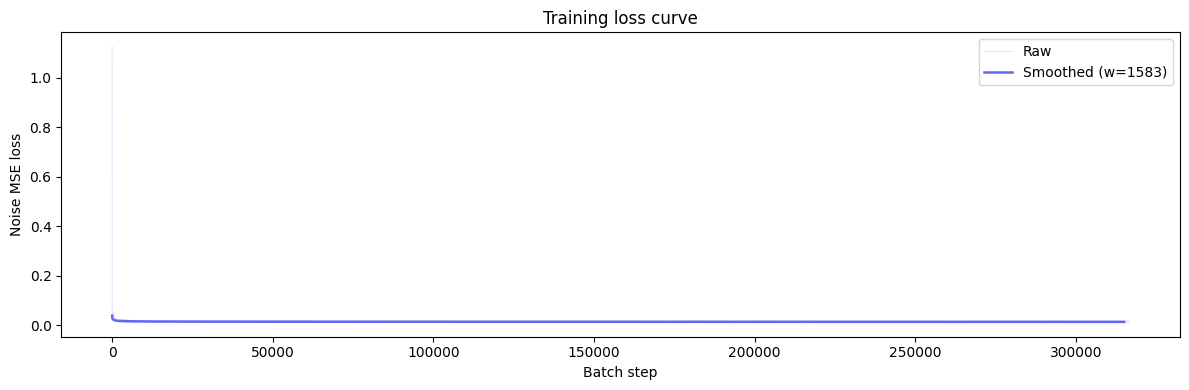

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np

ckpt = torch.load(
    "/home/rja3097/CelebA/celeba_conditional_diffusion_runs/checkpoint_latest.pt",
    map_location="cpu"
)
losses = ckpt["losses"]

# smooth
window = max(1, len(losses) // 200)
smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 4))
plt.plot(losses, alpha=0.15, color="#6366f1", linewidth=0.8, label="Raw")
plt.plot(smoothed, color="#6366f1", linewidth=1.8, label=f"Smoothed (w={window})")
plt.xlabel("Batch step")
plt.ylabel("Noise MSE loss")
plt.title("Training loss curve")
plt.legend()
plt.tight_layout()
plt.show()